# Investment Analysis: Capstone Summary Notebook

## Returns, Risk, Portfolios, Asset Pricing, and Market Efficiency

This notebook summarizes the essential ideas from the investment analysis lecture sequence.

The goal is to give students a coherent map of the course:

1. What returns are and how they are measured.
2. How risk and risk premia are defined.
3. How investor risk aversion shapes portfolio choice.
4. How diversification and covariance determine portfolio risk.
5. How optimal portfolios are constructed.
6. How the single-index model, CAPM, APT, and multifactor models explain expected returns.
7. How market efficiency affects active and passive investing.
8. How empirical evidence tests asset-pricing models.
9. Why puzzles such as the equity premium puzzle remain important.

This is a summary notebook, not a replacement for the full lecture notebooks.

# 1. Setup

We use small simulations and, if available, the uploaded JKP factor file:

```text
[usa]_[all_factors]_[monthly]_[vw_cap].csv
```

The JKP file is used only for compact empirical illustrations of factor returns.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2050)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

JKP_FILE = Path("/mnt/data/[usa]_[all_factors]_[monthly]_[vw_cap].csv")
if not JKP_FILE.exists():
    JKP_FILE = Path("[usa]_[all_factors]_[monthly]_[vw_cap].csv")

print("JKP factor file exists:", JKP_FILE.exists())

JKP factor file exists: True


In [2]:
def ols(y, X, add_const=True):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    if add_const:
        X = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.pinv(X.T @ X) @ X.T @ y
    fitted = X @ beta
    resid = y - fitted
    n, k = X.shape
    s2 = resid @ resid / max(n-k, 1)
    cov_beta = s2 * np.linalg.pinv(X.T @ X)
    se = np.sqrt(np.diag(cov_beta))
    t = beta / se
    denom = ((y - y.mean()) @ (y - y.mean()))
    r2 = np.nan if denom == 0 else 1 - (resid @ resid) / denom
    return {"coef": beta, "se": se, "t": t, "resid": resid, "fitted": fitted, "r2": r2}

def annualized_summary(returns, periods_per_year=12):
    out = pd.DataFrame(index=returns.columns)
    out["Mean Ann. Return"] = returns.mean() * periods_per_year
    out["Ann. Volatility"] = returns.std(ddof=1) * np.sqrt(periods_per_year)
    out["Sharpe Ratio"] = out["Mean Ann. Return"] / out["Ann. Volatility"]
    out["Skewness"] = returns.skew()
    out["Excess Kurtosis"] = returns.kurtosis()
    out["Worst Period"] = returns.min()
    out["Best Period"] = returns.max()
    out["Observations"] = returns.count()
    return out.sort_values("Sharpe Ratio", ascending=False)

def drawdown_from_returns(r):
    wealth = (1 + pd.Series(r).fillna(0)).cumprod()
    return wealth / wealth.cummax() - 1

# 2. Return Concepts

The total return on an asset has two parts:

1. income return,
2. capital gain return.

If an asset begins at price \(P_0\), ends at price \(P_1\), and pays income \(D_1\), then:

$$
R = \frac{P_1 + D_1 - P_0}{P_0}.
$$

Equivalently:

$$
R = \frac{D_1}{P_0} + \frac{P_1-P_0}{P_0}.
$$

The gross return is:

$$
1+R = \frac{P_1+D_1}{P_0}.
$$

In [3]:
P0, P1, D1 = 100, 108, 3
income_return = D1 / P0
capital_gain = (P1 - P0) / P0
total_return = income_return + capital_gain
log_return = np.log(1 + total_return)

pd.DataFrame({
    "Concept": ["Income return", "Capital gain return", "Total simple return", "Log return"],
    "Value": [income_return, capital_gain, total_return, log_return]
})

,Concept,Value
0,Income return,0.0300
1,Capital gain return,0.0800
2,Total simple return,0.1100
3,Log return,0.1044


# 3. Compounding, APR, EAR, and Real Returns

If the annual percentage rate is \(APR\) and compounding occurs \(m\) times per year, the effective annual rate is:

$$
EAR=\left(1+\frac{APR}{m}\right)^m-1.
$$

With continuous compounding:

$$
FV = PV e^{rT}.
$$

The exact relation between nominal rates, real rates, and inflation is:

$$
1+i=(1+r)(1+\pi).
$$

The Fisher approximation is:

$$
i \approx r+\mathbb{E}[\pi].
$$

In [4]:
PV, apr, T_years = 10_000, 0.08, 10
freqs = {"Annual": 1, "Quarterly": 4, "Monthly": 12, "Daily": 365}
rows = []
for name, m in freqs.items():
    fv = PV * (1 + apr/m)**(m*T_years)
    ear = (1 + apr/m)**m - 1
    rows.append([name, ear, fv])
rows.append(["Continuous", np.exp(apr)-1, PV*np.exp(apr*T_years)])
pd.DataFrame(rows, columns=["Compounding", "Effective Annual Rate", "Future Value after 10 Years"])

,Compounding,Effective Annual Rate,Future Value after 10 Years
0,Annual,0.0800,"21,589.2500"
1,Quarterly,0.0824,"22,080.3966"
2,Monthly,0.0830,"22,196.4023"
3,Daily,0.0833,"22,253.4585"
4,Continuous,0.0833,"22,255.4093"


# 4. Basic Statistics of Returns

For returns \(R_1,\ldots,R_T\), the arithmetic average is:

$$
\bar{R}_A=\frac{1}{T}\sum_{t=1}^T R_t.
$$

The geometric average is:

$$
\bar{R}_G=\left[\prod_{t=1}^T(1+R_t)\right]^{1/T}-1.
$$

Variance and standard deviation measure dispersion:

$$
\sigma^2=\mathbb{E}[(R-\mu)^2], \qquad \sigma=\sqrt{\sigma^2}.
$$

Skewness describes asymmetry; kurtosis describes tail thickness.

,Value
Arithmetic Mean Monthly,0.0102
Geometric Mean Monthly,0.0092
Monthly Std Dev,0.0436
Variance,0.0019
Skewness,0.3441
Excess Kurtosis,0.2796
Annualized Mean,0.1219
Annualized Std Dev,0.1510


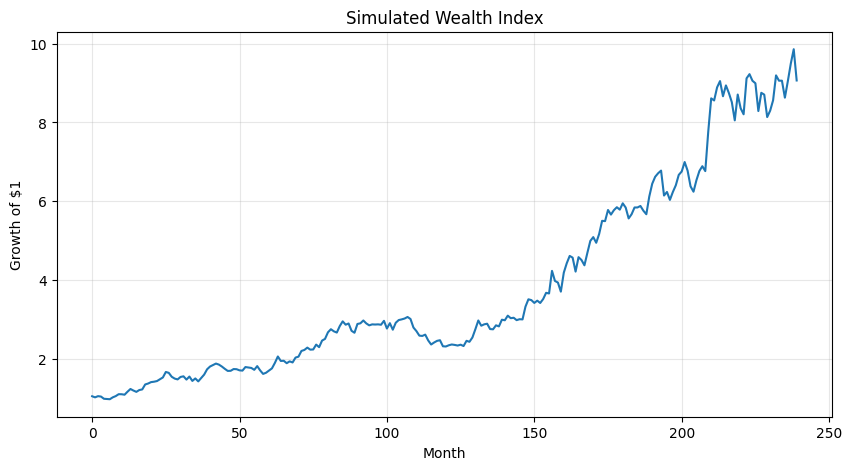

In [5]:
months = 240
sim_returns = pd.Series(np.random.normal(0.007, 0.045, months), name="Monthly Return")
stats = pd.Series({
    "Arithmetic Mean Monthly": sim_returns.mean(),
    "Geometric Mean Monthly": (1+sim_returns).prod()**(1/len(sim_returns))-1,
    "Monthly Std Dev": sim_returns.std(ddof=1),
    "Variance": sim_returns.var(ddof=1),
    "Skewness": sim_returns.skew(),
    "Excess Kurtosis": sim_returns.kurtosis(),
    "Annualized Mean": sim_returns.mean()*12,
    "Annualized Std Dev": sim_returns.std(ddof=1)*np.sqrt(12)
})
display(stats.to_frame("Value"))
wealth = (1 + sim_returns).cumprod()
plt.figure(figsize=(10,5))
plt.plot(wealth)
plt.title("Simulated Wealth Index")
plt.xlabel("Month")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.show()

# 5. Risk, Risk Premia, and the Stochastic Discount Factor

A risk premium is the expected return above a safe rate:

$$
\mathbb{E}[R_i]-R_f.
$$

Modern asset pricing begins from:

$$
P_i=\mathbb{E}[M X_i],
$$

where \(M\) is the stochastic discount factor and \(X_i\) is the asset payoff.

In return form:

$$
1=\mathbb{E}[M R_i].
$$

This implies:

$$
\mathbb{E}[R_i]-R_f=-R_f\operatorname{Cov}(M,R_i).
$$

Assets that perform poorly when marginal utility is high require higher expected returns.

In [6]:
r = sim_returns
VaR_5 = -np.quantile(r, 0.05)
ES_5 = -r[r <= np.quantile(r, 0.05)].mean()
downside_dev = np.sqrt(np.mean(np.minimum(r, 0)**2))
max_dd = drawdown_from_returns(r).min()
pd.Series({
    "Monthly Std Dev": r.std(ddof=1),
    "5% Value at Risk": VaR_5,
    "5% Expected Shortfall": ES_5,
    "Lower Partial Std Dev": downside_dev,
    "Maximum Drawdown": max_dd
}).to_frame("Risk Measure")

,Risk Measure
Monthly Std Dev,0.0436
5% Value at Risk,0.0599
5% Expected Shortfall,0.0709
Lower Partial Std Dev,0.0238
Maximum Drawdown,-0.2441


# 6. Risk Aversion and Utility

A common mean-variance utility approximation is:

$$
U=\mathbb{E}[R]-\frac{A}{2}\sigma^2,
$$

where \(A\) measures risk aversion.

The certainty equivalent is a guaranteed return or cash amount that an individual would accept today rather than taking a chance on a higher, but uncertain, future return. It represents the exact point of indifference between a risky investment and a safe, guaranteed payout. It could be equal to the utility function above:

$$
CE=\mathbb{E}[R]-\frac{A}{2}\sigma^2.
$$

Common utility functions include log utility, CRRA utility, and CARA utility.

In [7]:
mu, sigma = 0.08, 0.18
A_values = [1, 2, 3, 5, 8]
pd.DataFrame({
    "Risk Aversion A": A_values,
    "Expected Return": mu,
    "Volatility": sigma,
    "Certainty Equivalent": [mu - 0.5*A*sigma**2 for A in A_values]
})

,Risk Aversion A,Expected Return,Volatility,Certainty Equivalent
0,1,0.0800,0.1800,0.0638
1,2,0.0800,0.1800,0.0476
2,3,0.0800,0.1800,0.0314
3,5,0.0800,0.1800,-0.0010
4,8,0.0800,0.1800,-0.0496


# 7. Capital Allocation Across Risk-Free and Risky Assets

If fraction \(y\) is allocated to risky portfolio \(P\):

$$
\mathbb{E}[R_C]=R_f+y(\mathbb{E}[R_P]-R_f),
$$

and:

$$
\sigma_C=|y|\sigma_P.
$$

The capital allocation line has slope:

$$
S_P=\frac{\mathbb{E}[R_P]-R_f}{\sigma_P}.
$$

This is the Sharpe ratio. With mean-variance utility:

$$
y^*=\frac{\mathbb{E}[R_P]-R_f}{A\sigma_P^2}.
$$

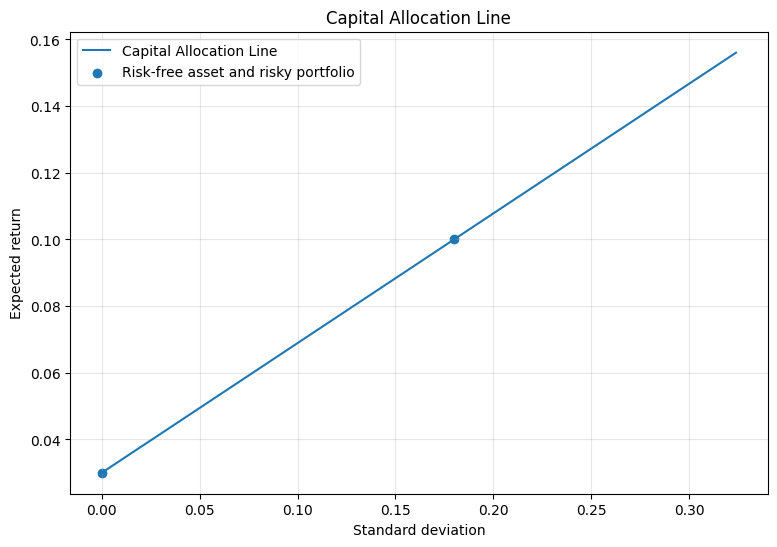

,A,Optimal risky weight y*
0,1,2.1605
1,2,1.0802
2,3,0.7202
3,5,0.4321
4,8,0.2701


In [8]:
rf, mu_p, sigma_p = 0.03, 0.10, 0.18
y_grid = np.linspace(0, 1.8, 100)
mu_c = rf + y_grid*(mu_p-rf)
sigma_c = y_grid*sigma_p
plt.figure(figsize=(9,6))
plt.plot(sigma_c, mu_c, label="Capital Allocation Line")
plt.scatter([0, sigma_p], [rf, mu_p], label="Risk-free asset and risky portfolio")
plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
plt.title("Capital Allocation Line")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
pd.DataFrame({"A": A_values, "Optimal risky weight y*": [(mu_p-rf)/(A*sigma_p**2) for A in A_values]})

# 8. Diversification and Portfolio Risk

For a two-asset portfolio:

$$
\mathbb{E}[R_p]=w_A\mu_A+(1-w_A)\mu_B.
$$

Variance is:

$$
\sigma_p^2=w_A^2\sigma_A^2+(1-w_A)^2\sigma_B^2+2w_A(1-w_A)\rho_{AB}\sigma_A\sigma_B.
$$

Diversification works when correlations are less than one.

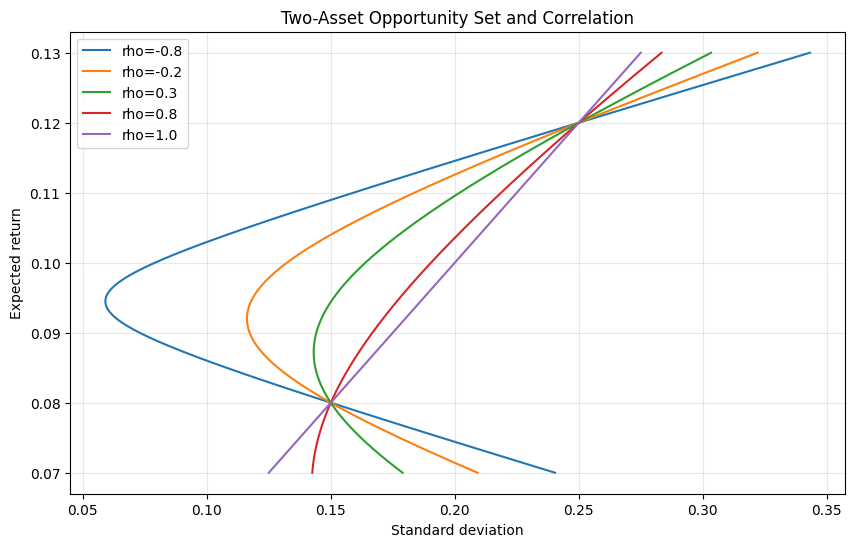

In [9]:
mu_A, mu_B = 0.08, 0.12
sig_A, sig_B = 0.15, 0.25
w = np.linspace(-0.25, 1.25, 300)
plt.figure(figsize=(10,6))
for rho in [-0.8, -0.2, 0.3, 0.8, 1.0]:
    mu_port = w*mu_A + (1-w)*mu_B
    var_port = w**2*sig_A**2 + (1-w)**2*sig_B**2 + 2*w*(1-w)*rho*sig_A*sig_B
    sd_port = np.sqrt(np.maximum(var_port, 0))
    plt.plot(sd_port, mu_port, label=f"rho={rho}")
plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
plt.title("Two-Asset Opportunity Set and Correlation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 9. Markowitz Portfolio Optimization

For many risky assets:

$$
\mathbb{E}[R_p]=\mathbf{w}'\boldsymbol{\mu}, \qquad \sigma_p^2=\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}.
$$

The global minimum-variance portfolio is:

$$
\mathbf{w}_{GMV}=\frac{\boldsymbol{\Sigma}^{-1}\mathbf{1}}{\mathbf{1}'\boldsymbol{\Sigma}^{-1}\mathbf{1}}.
$$

The tangency portfolio is:

$$
\mathbf{w}_T=\frac{\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}-R_f\mathbf{1})}{\mathbf{1}'\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}-R_f\mathbf{1})}.
$$

In [10]:
mu_vec = np.array([0.06, 0.10, 0.14])
Sigma = np.array([[0.0100, 0.0060, 0.0040],[0.0060, 0.0400, 0.0180],[0.0040, 0.0180, 0.0900]])
ones = np.ones(3)
invS = np.linalg.inv(Sigma)
w_gmv = invS @ ones / (ones @ invS @ ones)
w_tan = invS @ (mu_vec - rf*ones)
w_tan = w_tan / (ones @ invS @ (mu_vec-rf*ones))
display(pd.DataFrame({"Asset": ["Asset 1", "Asset 2", "Asset 3"], "GMV Weight": w_gmv, "Tangency Weight": w_tan}))
print("GMV return:", w_gmv @ mu_vec, "GMV vol:", np.sqrt(w_gmv @ Sigma @ w_gmv))
print("Tangency return:", w_tan @ mu_vec, "Tangency vol:", np.sqrt(w_tan @ Sigma @ w_tan))

,Asset,GMV Weight,Tangency Weight
0,Asset 1,0.8689,0.5066
1,Asset 2,0.0820,0.2599
2,Asset 3,0.0492,0.2335


GMV return: 0.06721311475409834 GMV vol: 0.09683516499871248
Tangency return: 0.0890748898678414 Tangency vol: 0.12200750501290358


# 10. The Single-Index Model

The single-index model says:

$$
R_i-R_f=\alpha_i+\beta_i(R_M-R_f)+\epsilon_i.
$$

Beta is:

$$
\beta_i=\frac{\operatorname{Cov}(R_i,R_M)}{\operatorname{Var}(R_M)}.
$$

Variance decomposes into:

$$
\sigma_i^2=\beta_i^2\sigma_M^2+\sigma_{\epsilon_i}^2.
$$

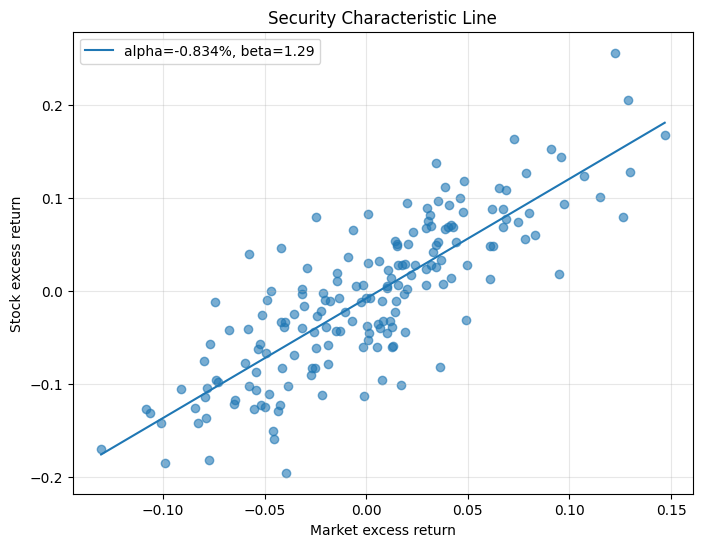

,Estimate
Estimated alpha,-0.0083
Estimated beta,1.2865
R-squared,0.6767
Residual volatility,0.0471


In [11]:
T = 180
market_excess = np.random.normal(0.006, 0.045, T)
true_alpha, true_beta = 0.001, 1.25
stock_excess = true_alpha + true_beta*market_excess + np.random.normal(0, 0.05, T)
res = ols(stock_excess, market_excess)
alpha_hat, beta_hat = res["coef"]
plt.figure(figsize=(8,6))
plt.scatter(market_excess, stock_excess, alpha=0.6)
xline = np.linspace(market_excess.min(), market_excess.max(), 100)
plt.plot(xline, alpha_hat + beta_hat*xline, label=f"alpha={alpha_hat:.3%}, beta={beta_hat:.2f}")
plt.xlabel("Market excess return")
plt.ylabel("Stock excess return")
plt.title("Security Characteristic Line")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
pd.Series({"Estimated alpha": alpha_hat, "Estimated beta": beta_hat, "R-squared": res["r2"], "Residual volatility": np.std(res["resid"], ddof=1)}).to_frame("Estimate")

# 11. The CAPM

The CAPM predicts:

$$
\mathbb{E}[R_i]-R_f=\beta_i(\mathbb{E}[R_M]-R_f).
$$

Expected return depends on systematic risk, not total volatility.

The security market line describes expected returns for individual assets as a function of beta.

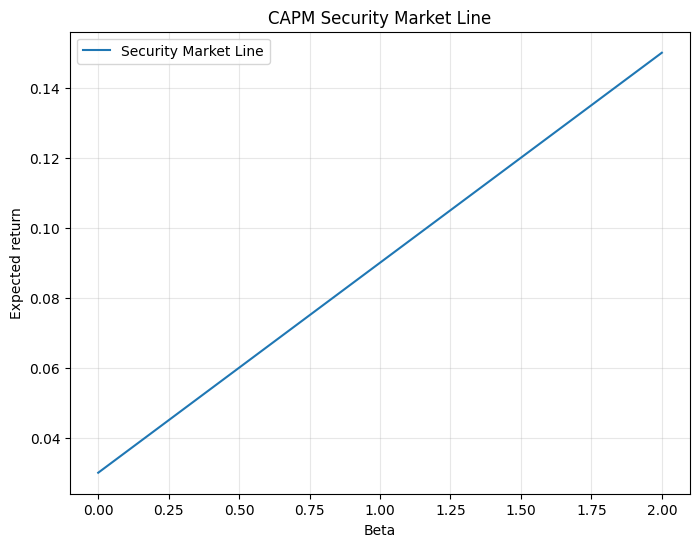

In [12]:
betas = np.linspace(0, 2, 100)
market_premium = 0.06
expected_returns = rf + betas*market_premium
plt.figure(figsize=(8,6))
plt.plot(betas, expected_returns, label="Security Market Line")
plt.xlabel("Beta")
plt.ylabel("Expected return")
plt.title("CAPM Security Market Line")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 12. Multifactor Models and APT

The APT starts from no-arbitrage. If returns have a factor structure:

$$
R_i=\mathbb{E}[R_i]+\beta_{i1}F_1+\cdots+\beta_{ik}F_k+\epsilon_i,
$$

then well-diversified portfolios eliminate idiosyncratic risk. No arbitrage implies:

$$
\mathbb{E}[R_i]-R_f=\beta_{i1}\lambda_1+\cdots+\beta_{ik}\lambda_k.
$$

# 13. Fama-French Factors and the Factor Zoo

The Fama-French three-factor model is:

$$
R_i-R_f=\alpha_i+\beta_M(Mkt-RF)+\beta_S SMB+\beta_H HML+\epsilon_i.
$$

The five-factor model adds profitability and investment.

Common factors include market, size, value, momentum, profitability, investment, quality, low volatility, and liquidity.

The factor zoo problem is that many factors may be discovered by data mining.

,Mean Ann. Return,Ann. Volatility,Sharpe Ratio,Skewness,Excess Kurtosis,Worst Period,Best Period,Observations
name,,,,,,,,
cop_at,0.0608,0.0578,1.0523,0.6473,3.3839,-0.0531,0.0957,890
noa_at,0.0520,0.0552,0.9430,0.2785,2.9521,-0.0639,0.1049,890
resff3_12_1,0.0684,0.0758,0.9019,-0.3492,6.3441,-0.1603,0.1170,872
nfna_gr1a,0.0297,0.0349,0.8524,0.0077,2.0610,-0.0436,0.0494,890
fnl_gr1a,0.0299,0.0355,0.8419,-0.0029,1.8307,-0.0436,0.0472,890
dsale_dinv,0.0334,0.0402,0.8314,-0.1200,2.3432,-0.0665,0.0575,878
nncoa_gr1a,0.0479,0.0577,0.8291,0.9134,6.7775,-0.0730,0.1177,890
cop_atl1,0.0510,0.0618,0.8255,0.3866,2.8798,-0.0741,0.0962,890
oaccruals_ni,0.0407,0.0493,0.8251,-0.0527,1.9797,-0.0746,0.0660,890


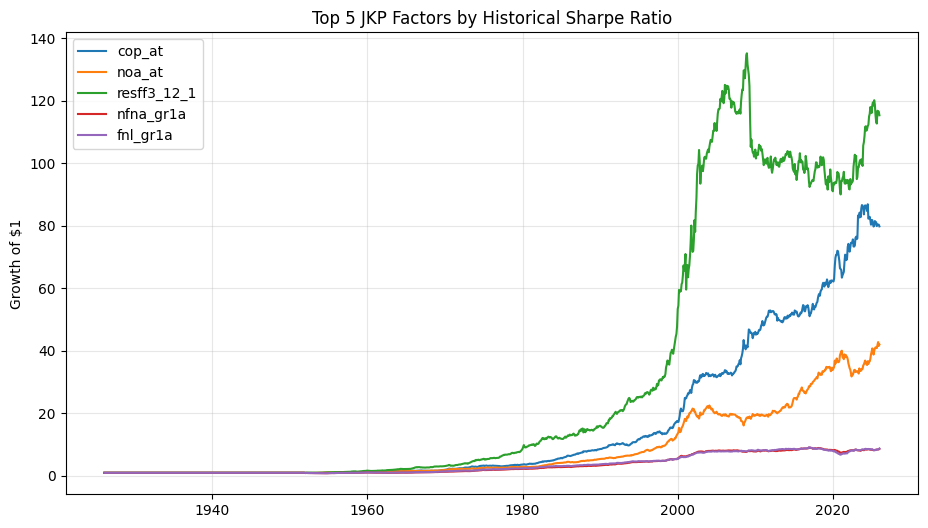

In [13]:
if JKP_FILE.exists():
    jkp_long = pd.read_csv(JKP_FILE, encoding="utf-8-sig")
    jkp_long["date"] = pd.to_datetime(jkp_long["date"])
    jkp_factors = jkp_long.pivot_table(index="date", columns="name", values="ret", aggfunc="mean").sort_index()
    jkp_summary = annualized_summary(jkp_factors)
    display(jkp_summary.head(15))
    top5 = jkp_summary.head(5).index.tolist()
    wealth = (1 + jkp_factors[top5].fillna(0)).cumprod()
    plt.figure(figsize=(11,6))
    for col in wealth.columns:
        plt.plot(wealth.index, wealth[col], label=col)
    plt.title("Top 5 JKP Factors by Historical Sharpe Ratio")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("JKP file not available.")

# 14. Market Efficiency

The Efficient Market Hypothesis asks how information is reflected in prices.

## Weak-form efficiency

Prices reflect past prices and trading data.

## Semi-strong-form efficiency

Prices reflect public information.

## Strong-form efficiency

Prices reflect public and private information.

Efficient prices often look like random walks because news is unpredictable.

# 15. Event Studies and Tests of Efficiency

An event study measures price reaction to information events.

The abnormal return is:

$$
AR_{i,t}=R_{i,t}-E[R_{i,t}].
$$

The cumulative abnormal return is:

$$
CAR_i(T_1,T_2)=\sum_{t=T_1}^{T_2}AR_{i,t}.
$$

The joint hypothesis problem says every test of market efficiency is also a test of the expected-return model used to calculate abnormal returns.

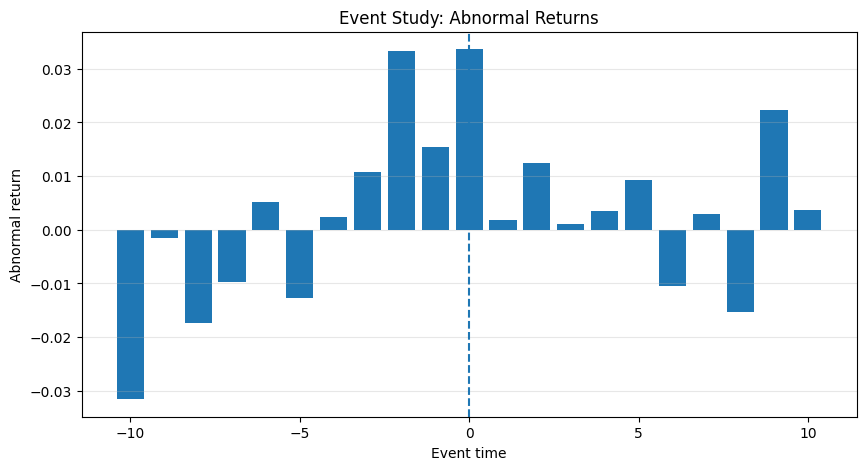

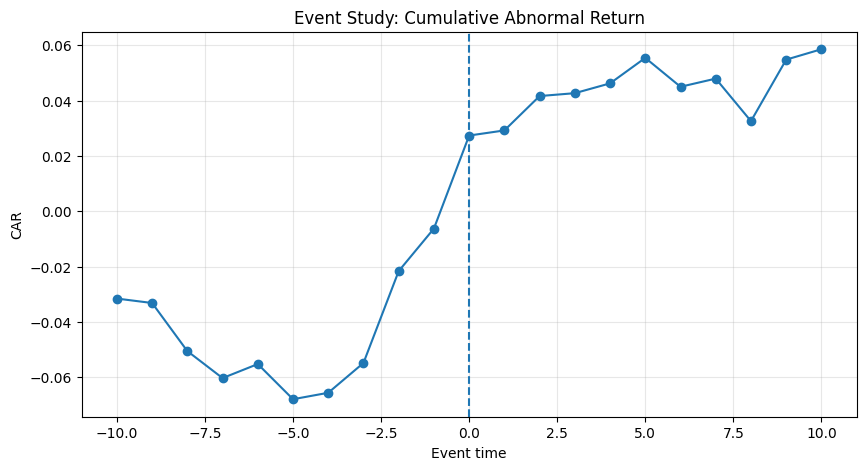

In [14]:
n_days, event_day = 180, 120
market = np.random.normal(0.0004, 0.012, n_days)
stock = 0.0002 + 1.1*market + np.random.normal(0, 0.018, n_days)
stock[event_day-2:event_day] += [0.015, 0.020]
stock[event_day] += 0.060
est = slice(0, event_day-20)
res = ols(stock[est], market[est])
alpha, beta = res["coef"]
window = np.arange(event_day-10, event_day+11)
AR = stock[window] - (alpha + beta*market[window])
CAR = np.cumsum(AR)
plt.figure(figsize=(10,5))
plt.bar(np.arange(-10,11), AR)
plt.axvline(0, linestyle="--")
plt.title("Event Study: Abnormal Returns")
plt.xlabel("Event time")
plt.ylabel("Abnormal return")
plt.grid(True, axis="y", alpha=0.3)
plt.show()
plt.figure(figsize=(10,5))
plt.plot(np.arange(-10,11), CAR, marker="o")
plt.axvline(0, linestyle="--")
plt.title("Event Study: Cumulative Abnormal Return")
plt.xlabel("Event time")
plt.ylabel("CAR")
plt.grid(True, alpha=0.3)
plt.show()

# 16. Empirical Evidence on Security Returns

Empirical asset pricing asks whether expected returns line up with risk exposures.

Common evidence includes two-pass tests of the CAPM, beta-sorted portfolio tests, Fama-MacBeth regressions, time-series tests of multifactor alphas, Fama-French style factor regressions, anomaly portfolio returns, mutual fund performance studies, and event studies.

The CAPM is elegant but empirically incomplete. Multifactor models often explain more cross-sectional return variation, but many factors raise concerns about data mining, transaction costs, and interpretation.

# 17. Two-Pass Tests of Asset Pricing

A two-pass test has two stages.

First, estimate betas:

$$
R_{i,t}-R_{f,t}=\alpha_i+\beta_i(R_{M,t}-R_{f,t})+\epsilon_{i,t}.
$$

Second, estimate the cross-sectional price of risk:

$$
R_{i,t}-R_{f,t}=\gamma_{0,t}+\gamma_{1,t}\hat{\beta}_i+\eta_{i,t}.
$$

Average the \(\gamma\)'s across time.

In [15]:
T, N = 180, 80
lambda_m, sigma_m = 0.006, 0.045
true_betas = np.linspace(0.5, 1.7, N)
market_shock = np.random.normal(0, sigma_m, T)
market_excess = lambda_m + market_shock
R = np.zeros((T, N))
for i,b in enumerate(true_betas):
    R[:,i] = b*lambda_m + b*market_shock + np.random.normal(0, 0.07, T)
beta_hat = np.array([ols(R[:,i], market_excess)["coef"][1] for i in range(N)])
gammas = []
for t in range(T):
    gammas.append(ols(R[t,:], beta_hat)["coef"])
gammas = pd.DataFrame(gammas, columns=["gamma0", "gamma1"])
fm = pd.DataFrame({"Mean": gammas.mean(), "SE": gammas.std(ddof=1)/np.sqrt(T)})
fm["t-stat"] = fm["Mean"]/fm["SE"]
display(fm)

,Mean,SE,t-stat
gamma0,-0.0006,0.0017,-0.3432
gamma1,0.0058,0.0036,1.6209


# 18. Tests of Multifactor Models

A multifactor time-series regression is:

$$
R_i-R_f=\alpha_i+\beta_{i1}F_1+\cdots+\beta_{ik}F_k+\epsilon_i.
$$

If the model prices assets correctly, alphas should be zero.

Multifactor models improve empirical fit but raise interpretive questions: are factors true risk factors, mispricing signals, proxies for omitted risks, or data-mined patterns?

# 19. Equity Premium Puzzle

The equity premium is the average return of stocks above safe assets.

With power utility:

$$
M_{t+1}=\beta\left(\frac{C_{t+1}}{C_t}\right)^{-\gamma}.
$$

Because aggregate consumption growth is smooth, simple consumption-based models often require implausibly high risk aversion to explain the historical equity premium.

In [16]:
equity_premium = 0.06
equity_vol = 0.18
consumption_vol = 0.02
corr = 0.25
cov = equity_vol * consumption_vol * corr
implied_gamma = equity_premium / cov
pd.Series({
    "Equity premium": equity_premium,
    "Equity volatility": equity_vol,
    "Consumption growth volatility": consumption_vol,
    "Correlation": corr,
    "Covariance": cov,
    "Implied risk aversion gamma": implied_gamma
}).to_frame("Value")

,Value
Equity premium,0.0600
Equity volatility,0.1800
Consumption growth volatility,0.0200
Correlation,0.2500
Covariance,0.0009
Implied risk aversion gamma,66.6667


# 20. Course Map: How the Pieces Fit Together

The sequence of ideas is:

1. **Returns** measure compensation for investing.
2. **Risk statistics** describe the distribution of returns.
3. **Risk aversion** explains why investors require compensation for uncertainty.
4. **Capital allocation** combines risky portfolios with safe assets.
5. **Diversification** reduces idiosyncratic risk.
6. **Markowitz optimization** uses means, variances, and covariances to construct efficient portfolios.
7. **Single-index models** explain covariance using market exposure.
8. **CAPM** prices market beta.
9. **APT and multifactor models** price multiple systematic risks.
10. **Fama-French models** summarize major empirical return patterns.
11. **Market efficiency** asks whether information is already in prices.
12. **Empirical tests** evaluate whether returns are explained by risk exposures or anomalies.
13. **Asset-pricing puzzles** show where simple models remain incomplete.

The unifying principle is:

> Expected returns are compensation for bearing risks that matter to investors and cannot be diversified away.

# 21. Final Takeaways

1. Total return equals income return plus capital gain return.
2. Arithmetic averages describe typical one-period returns; geometric averages describe compound growth.
3. Risk includes volatility, downside risk, tail risk, drawdown, and covariance with bad states.
4. Risk-averse investors require risk premia.
5. The Sharpe ratio is the slope of the capital allocation line.
6. Diversification reduces idiosyncratic risk but not systematic risk.
7. Portfolio variance depends on covariances, not just individual variances.
8. Markowitz optimization identifies efficient risky portfolios.
9. The CAPM predicts expected returns are linear in market beta.
10. The single-index model decomposes returns into market exposure and firm-specific residuals.
11. APT and multifactor models generalize asset pricing to multiple systematic risks.
12. Fama-French factors describe important empirical patterns in size, value, profitability, and investment.
13. Market efficiency implies that easy abnormal returns should be difficult to earn after risk and costs.
14. Event studies measure how prices respond to information.
15. Empirical tests are complicated by measurement error, omitted factors, model dependence, data mining, and finite samples.
16. The equity premium puzzle shows that simple consumption-based models struggle to explain observed stock returns.
17. Investment analysis combines theory, statistics, institutional details, and economic judgment.